In [1]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=DESKTOP-NFREKTF\SQLEXPRESS;"
    "DATABASE=cdnow;"
    "Trusted_Connection=yes;"  # Windows auth
)

df = pd.read_sql("SELECT * FROM gold.cdnow", conn)
conn.close()

C:\Users\dell\AppData\Local\Temp\ipykernel_15564\3139527603.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM gold.cdnow", conn)


In [2]:
df.head()

,customer_id,duration,event,total_spent,total_orders
0,2917,0,1,86.79,1
1,5834,0,1,14.37,1
2,11407,0,1,105.93,1
3,14324,0,1,6.79,1
4,19897,13,0,436.49,5


In [3]:
!pip install lifelines

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4048 sha256=fa386a6be4e4c2bb61b5b930ad4abd7a8896bc55d07aa42a98b2ed586e4bb3c9
  Stored in directory: c:\users\dell\appdata\local\pip\cache\wheels\7e\16\46\9477f188924292d3bf1fb8fb42844201591abfc19b7ba6d868
Successfully built autograd-gamma

   -------- ------------------------------- 1/5 [autograd]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   -------------------------------- ------- 4/5 [lifelines]
   -------------------------------- ------- 4/5 [lifelines]
   ---------------------------------------- 5/5 [lifelines]



  DEPRECATION: Building 'autograd-gamma' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autograd-gamma'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [15]:
from lifelines import KaplanMeierFitter , CoxPHFitter
from matplotlib import pyplot as plt
import seaborn as sns 

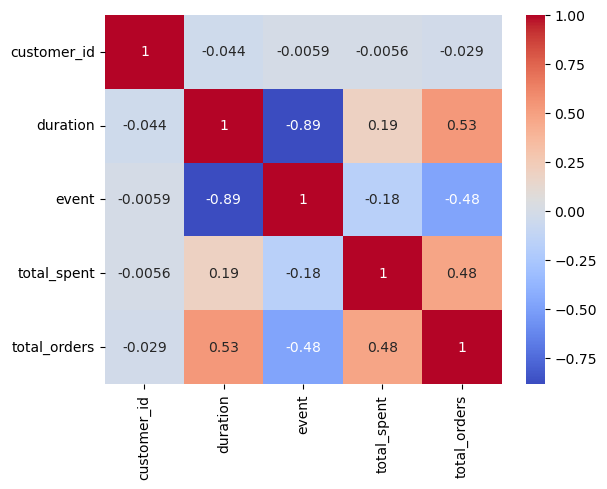

In [16]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

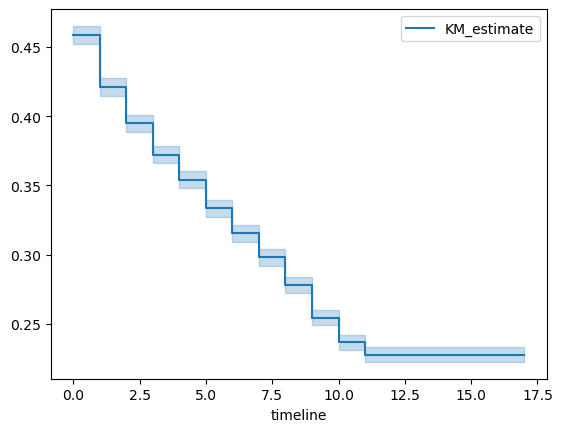

In [7]:
km = KaplanMeierFitter()
km.fit(durations=df["duration"], event_observed=df["event"])
km.plot_survival_function()
plt.show()

### Data starts at 0.45-0.46 so most of the customers have a duration of 0 which means they are one time buyers. At 10 months only 22% have  stayped on with their cd's which means these are our loyal consumers

In [12]:
cx = CoxPHFitter()
cx_df = df.loc[:,df.columns != "customer_id"]
cx.fit(cx_df, duration_col="duration", event_col="event")
print(cx.summary)

                  coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                     
total_spent   0.000014   1.000014  0.000007    1.760808e-07        0.000029   
total_orders -0.955363   0.384672  0.010504   -9.759509e-01       -0.934775   

              exp(coef) lower 95%  exp(coef) upper 95%  cmp to          z  \
covariate                                                                   
total_spent              1.000000             1.000029     0.0   1.984161   
total_orders             0.376834             0.392674     0.0 -90.950620   

                     p  -log2(p)  
covariate                         
total_spent   0.047238  4.403913  
total_orders  0.000000       inf  


### SO a unit increase in total_send does not change a lot but a unit increase of 1 unit in total_orders means the consumer will churn at a rate of 38.46% meaning 61.6% reduction in the churn hazard.

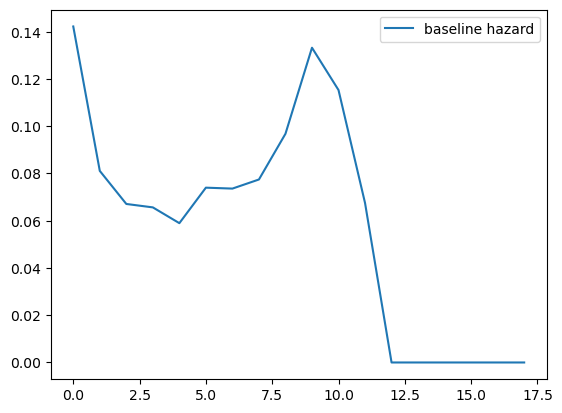

In [19]:
cx.baseline_hazard_.plot()
plt.show()  

In [22]:
cx_df.head()

,duration,event,total_spent,total_orders
0,0,1,86.79,1
1,0,1,14.37,1
2,0,1,105.93,1
3,0,1,6.79,1
4,13,0,436.49,5


In [24]:
new_cx_df = cx_df.loc[cx_df['event']==0]
new_cx_df_not_churned = new_cx_df['duration']

In [25]:
cx.predict_survival_function(new_cx_df,conditional_after=new_cx_df_not_churned)

print(cx.predict_median(new_cx_df,conditional_after=new_cx_df_not_churned))

4        inf
8        inf
20       inf
25       inf
34       inf
        ... 
23554    inf
23556    inf
23559    inf
23566    inf
23567    inf
Name: 0.5, Length: 5374, dtype: float64


### Fair as the survival curve never crossed 50% can we check if our data can be segmented to se if survival curve does cross 50%?

In [ ]:
df['total_orders'].mode()

0    1
Name: total_orders, dtype: int64